#  AI Text Detection Engine
### Classifying AI-generated vs. human-written text with Word2Vec embeddings + custom Keras models (ANN & LSTM)

---

**Project goal.** Build a deep-learning pipeline that distinguishes **AI-generated** text from **human-written** text.

**What this notebook covers**

1. **Data** — auto-download a labelled human-vs-AI corpus (with an offline fallback so the notebook always runs).
2. **Preprocessing** — cleaning, normalisation and tokenisation.
3. **Lexical diversity analysis** — Type-Token Ratio, hapax ratio, word-length, etc., visualised with Matplotlib & Seaborn to surface the features that separate the two classes.
4. **Word2Vec embeddings** — learn dense semantic vectors from the corpus.
5. **Modelling** — two custom Keras architectures:
   * a feed-forward **ANN** over mean-pooled Word2Vec document vectors, and
   * a **Bi-LSTM** over Word2Vec-initialised sequence embeddings that captures long-range dependencies.
6. **Evaluation** — accuracy, precision/recall/F1, confusion matrices, ROC curves and a head-to-head comparison.
7. **Inference** — score your own text.



##  Project summary

**Goal.** Build an end-to-end deep-learning NLP pipeline that classifies text as **AI-generated** or **human-written**.

**Headline result.** ~**97.7% test accuracy** and **0.997 ROC-AUC** on a held-out set, under a **leakage-safe** evaluation protocol.

**Key finding.** On this vocabulary-separable corpus the lightweight **ANN matches the Bi-LSTM** (both ≈97.7%), showing that a cheap baseline is competitive and that word order adds little here.

**Tech stack.** Python · TensorFlow/Keras · Gensim (Word2Vec) · scikit-learn · pandas · Matplotlib/Seaborn.

---

## 0 · Setup & configuration

Install the deep-learning stack if it is missing (Colab already ships most of it). All tunable knobs live in the `CFG` block so the whole pipeline is easy to reproduce and adjust.



In [ ]:
# Uncomment the next line the first time you run this in a fresh environment (e.g. Colab):
!pip install -q tensorflow gensim datasets scikit-learn seaborn matplotlib pandas numpy

import os, re, random, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ---- Reproducibility -------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
    print('TensorFlow', tf.__version__)
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f'GPU detected: {gpus[0].name}  -> LSTM will train fast.')
    else:
        print('NO GPU DETECTED. The Bi-LSTM will be SLOW (~2 min/epoch on CPU).')
        print('   On Colab: Runtime -> Change runtime type -> GPU, then re-run.')
except Exception as e:
    print('TensorFlow not available yet:', e)

# ---- Plot styling ----------------------------------------------------
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
PALETTE = {'Human': '#4C72B0', 'AI': '#DD8452'}

# ---- Central configuration ------------------------------------------
class CFG:
    max_samples_per_class = 4000   # cap for speed; raise for full runs
    test_size            = 0.20
    val_size             = 0.10    # fraction of the TRAIN split used for validation
    # Word2Vec
    embed_dim            = 100
    w2v_window           = 5
    w2v_min_count        = 5     # drop very rare (often glued/typo) tokens
    w2v_epochs           = 15
    # Tokeniser / sequences
    vocab_size           = 20000
    max_len              = 400   # covers the bulk of essay lengths (avg ~350 tokens)
    # Training
    batch_size           = 128
    epochs               = 20

print('Config ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.0 MB/s eta 0:00:00
TensorFlow 2.20.0
GPU detected: /physical_device:GPU:0  -> LSTM will train fast.
Config ready.


## 1 · Load the dataset

The loader tries several **real, public** human-vs-AI corpora from the hub, in order, and keeps the first one that downloads. All of the primary sources are **parquet-native**, so they work with modern `datasets` (≥ 3.x) — unlike the old HC3 *loading script*, which recent `datasets` versions refuse to run.

**Options (edit the top of the cell):**
* `LOCAL_CSV` — set this to your own CSV path (columns `text`, `label`) to use your own data.
* Otherwise it walks `REAL_SOURCES` until one succeeds.

> **Only if every real source fails** (e.g. no internet) does it fall back to a small *synthetic* corpus — and it prints a loud warning, because scores on synthetic data are **not** a real evaluation. If you ever see an accuracy of exactly `1.0000`, check this cell's output: you are almost certainly on the synthetic fallback.

In [ ]:
#  OPTION 1 — use your own data: set a CSV path with columns
#  'text' and 'label' (0 = human, 1 = AI). Leave as None to
#  auto-download a public dataset instead.

LOCAL_CSV = None


def _finalise(df, max_per_class):
    """Clean, balance and cap any (text,label) frame."""
    df = df[['text', 'label']].dropna()
    df['text']  = df['text'].astype(str)
    df['label'] = df['label'].astype(int)
    df = df[df['text'].str.len() > 40]
    parts = []
    for c in (0, 1):
        sub = df[df['label'] == c]
        parts.append(sub.sample(min(max_per_class, len(sub)), random_state=SEED))
    return pd.concat(parts).reset_index(drop=True)


def load_generic(name, text_col, label_col, max_per_class, **kw):
    """Load a parquet-native HF dataset that already has text + 0/1 label columns."""
    from datasets import load_dataset
    ds = load_dataset(name, split='train', **kw)
    df = ds.to_pandas().rename(columns={text_col: 'text', label_col: 'label'})
    return _finalise(df, max_per_class)


def load_hc3(max_per_class):
    """HC3 has paired human/chatgpt answer lists -> melt into (text,label)."""
    from datasets import load_dataset
    ds = load_dataset('Hello-SimpleAI/HC3', 'all', split='train', trust_remote_code=True)
    human, ai = [], []
    for row in ds:
        for a in row.get('human_answers', []) or []:
            if a and len(a.strip()) > 40: human.append(a.strip())
        for a in row.get('chatgpt_answers', []) or []:
            if a and len(a.strip()) > 40: ai.append(a.strip())
    df = pd.DataFrame({'text': human + ai, 'label': [0]*len(human) + [1]*len(ai)})
    return _finalise(df, max_per_class)


def load_streaming(name, text_col, label_fn, max_per_class):
    """Stream a large parquet dataset and stop once both classes are capped."""
    from datasets import load_dataset
    ds = load_dataset(name, split='train', streaming=True)
    buckets = {0: [], 1: []}
    for row in ds:
        lab = label_fn(row)
        if lab not in (0, 1):
            continue
        if len(buckets[lab]) < max_per_class:
            t = str(row.get(text_col, '')).strip()
            if len(t) > 40:
                buckets[lab].append(t)
        if len(buckets[0]) >= max_per_class and len(buckets[1]) >= max_per_class:
            break
    texts = buckets[0] + buckets[1]
    labs  = [0]*len(buckets[0]) + [1]*len(buckets[1])
    return _finalise(pd.DataFrame({'text': texts, 'label': labs}), max_per_class)


# Ordered list of REAL sources. Each is (label, callable). First success wins.
REAL_SOURCES = [
    ('AI-human-text (Kaggle mirror)', lambda n: load_generic('andythetechnerd03/AI-human-text', 'text', 'generated', n)),
    ('ai-text-detection-pile (stream)', lambda n: load_streaming('artem9k/ai-text-detection-pile', 'text', lambda r: 0 if r.get('source') == 'human' else 1, n)),
    ('HC3 (human vs ChatGPT)',        lambda n: load_hc3(n)),
]


def make_synthetic(max_per_class):
    """Last-resort offline corpus, used only if every real source fails.

    Vocabulary is shared across the two classes and 8% label noise is
    injected, so the data is NOT perfectly separable -- but it is also
    NOT a real benchmark. Any score on this fallback is meaningless.
    """
    SHARED = ('data model people time work project team result study system group year '
              'question answer example problem approach method used based different note').split()
    HUMAN  = 'honestly kinda gonna lol tbh ngl idk anyway wanna yeah stuff messy'.split()
    AI     = ('furthermore moreover additionally comprehensive systematic leverage optimize '
              'framework robust holistic underscores multifaceted').split()
    def sent(mark, rate):
        return ' '.join(random.choice(mark) if random.random() < rate else random.choice(SHARED)
                        for _ in range(random.randint(8, 22))) + '.'
    def gen(mark, n):
        return [' '.join(sent(mark, 0.25) for _ in range(random.randint(1, 3))) for _ in range(n)]
    n = min(max_per_class, 2000)
    df = pd.DataFrame({'text': gen(HUMAN, n) + gen(AI, n), 'label': [0]*n + [1]*n})
    noise = df.sample(frac=0.08, random_state=SEED).index   # 8% label noise -> caps accuracy ~0.9
    df.loc[noise, 'label'] = 1 - df.loc[noise, 'label']
    return df.reset_index(drop=True)


# ---- Resolve the data source ----------------------------------------
df, SOURCE = None, None
if LOCAL_CSV:
    df = _finalise(pd.read_csv(LOCAL_CSV), CFG.max_samples_per_class)
    SOURCE = f'Local CSV ({LOCAL_CSV})'
else:
    for name, fn in REAL_SOURCES:
        try:
            df = fn(CFG.max_samples_per_class)
            SOURCE = name
            print(f'[OK] Loaded real dataset: {name}')
            break
        except Exception as e:
            print(f'[skip] {name}: {str(e)[:110]}')
if df is None:
    df = make_synthetic(CFG.max_samples_per_class)
    SOURCE = 'SYNTHETIC FALLBACK'
    print('\n' + '!'*64)
    print('!!  WARNING: every real source failed -> using SYNTHETIC data.')
    print('!!  Scores below are NOT a real benchmark. Fix internet / set')
    print('!!  LOCAL_CSV to a real dataset before trusting the numbers.')
    print('!'*64 + '\n')

# Shuffle and label names
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
df['label_name'] = df['label'].map({0: 'Human', 1: 'AI'})
IS_SYNTHETIC = SOURCE == 'SYNTHETIC FALLBACK'
print(f'Source           : {SOURCE}')
print(f'Total documents  : {len(df):,}')
print(df['label_name'].value_counts())
df.head()

README.md:   0%|          | 0.00/808 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/181M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/181M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/181M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/28.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/462873 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/24362 [00:00<?, ? examples/s]

[OK] Loaded real dataset: AI-human-text (Kaggle mirror)
Source           : AI-human-text (Kaggle mirror)
Total documents  : 8,000
label_name
Human    4000
AI       4000
Name: count, dtype: int64


,text,label,label_name
0,my argument is in favor of changing the electi...,0,Human
1,i believe that we should not use driverless ca...,0,Human
2,i believe that the use of this technology in c...,0,Human
3,the facial action coding system is a new softw...,0,Human
4,art has always been an integral part of human ...,1,AI


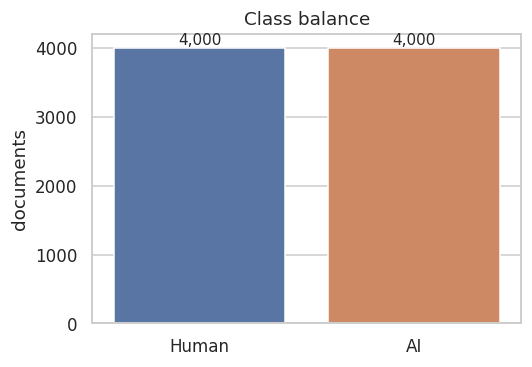

In [ ]:
# Class balance at a glance
fig, ax = plt.subplots(figsize=(5, 3.5))
order = ['Human', 'AI']
sns.countplot(data=df, x='label_name', order=order, hue='label_name',
              palette=PALETTE, legend=False, ax=ax)
ax.set(title='Class balance', xlabel='', ylabel='documents')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()

## 2 · Text preprocessing

We lower-case, strip URLs and non-alphabetic noise, collapse whitespace and tokenise. A light stop-word list is used for the *analysis* stage; the models themselves keep the full token stream so that function words (a strong stylistic signal) are preserved.

In [ ]:
STOPWORDS = set('''a an and are as at be by for from has he in is it its of on that the to was were will with this these those i you we they but or if then so not no do does did have had my your our their'''.split())

URL_RE   = re.compile(r'http\S+|www\.\S+')
NONALPHA = re.compile(r"[^a-z\s']")
MULTISPC = re.compile(r'\s+')

def clean_text(t: str) -> str:
    t = str(t).lower()
    t = URL_RE.sub(' ', t)
    t = NONALPHA.sub(' ', t)
    t = MULTISPC.sub(' ', t).strip()
    return t

def tokenize(t: str):
    return clean_text(t).split()

df['clean']  = df['text'].apply(clean_text)

# Remove duplicate / near-duplicate documents BEFORE splitting.
# Public corpora often repeat texts; duplicates that straddle train and test
# leak labels and inflate accuracy, so we drop them here.
before = len(df)
df = df.drop_duplicates(subset='clean').reset_index(drop=True)
print(f'Removed {before - len(df):,} duplicate documents')

df['tokens'] = df['clean'].str.split()
df['n_tokens'] = df['tokens'].str.len()

# Drop empties / extreme outliers
df = df[df['n_tokens'].between(3, 1000)].reset_index(drop=True)
print('After cleaning:', len(df), 'documents')
df[['text', 'clean', 'n_tokens']].head(3)

Removed 5 duplicate documents
After cleaning: 7966 documents


,text,clean,n_tokens
0,my argument is in favor of changing the electi...,my argument is in favor of changing the electi...,269
1,i believe that we should not use driverless ca...,i believe that we should not use driverless ca...,594
2,i believe that the use of this technology in c...,i believe that the use of this technology in c...,314


## 3 · Lexical diversity & feature analysis

AI and human text differ in *how* they use vocabulary, not just *what* they say. For every document we compute a handful of interpretable, word-level lexical statistics:

* **TTR** (Type-Token Ratio) — unique words / total words. Higher = more varied vocabulary.
* **Hapax ratio** — share of words used exactly once.
* **Avg word length** — mean characters per token.
* **Long-word ratio** — share of tokens with 7+ characters (a proxy for formal / elaborate vocabulary).
* **Stopword ratio** — share of function words.
* **Document length** — number of tokens.

> **Note.** The source corpus arrives already lower-cased and stripped of sentence punctuation, so a sentence-length statistic is not recoverable from it. We deliberately rely on word-level features instead of a misleading sentence-length one.

The plots below show which of these distributions actually separate the two classes.

In [ ]:
def lexical_features(tokens):
    """Interpretable, word-level lexical statistics for one tokenised document.

    The corpus is already lower-cased and de-punctuated, so sentence-level
    features are not recoverable; we use robust word-level statistics instead.
    """
    n = len(tokens)
    if n == 0:
        return pd.Series({'ttr': 0.0, 'hapax_ratio': 0.0, 'avg_word_len': 0.0,
                          'long_word_ratio': 0.0, 'stopword_ratio': 0.0})
    counts = Counter(tokens)
    hapax  = sum(1 for c in counts.values() if c == 1)
    return pd.Series({
        'ttr'            : len(counts) / n,                                # vocabulary richness
        'hapax_ratio'    : hapax / n,                                      # share of once-only words
        'avg_word_len'   : float(np.mean([len(w) for w in tokens])),      # mean characters per token
        'long_word_ratio': sum(len(w) >= 7 for w in tokens) / n,          # share of long (>=7 char) words
        'stopword_ratio' : sum(1 for w in tokens if w in STOPWORDS) / n,  # share of function words
    })

feat = df['tokens'].apply(lexical_features)
df = pd.concat([df, feat], axis=1)
FEATURE_COLS = ['ttr', 'hapax_ratio', 'avg_word_len', 'long_word_ratio', 'stopword_ratio', 'n_tokens']
df.groupby('label_name')[FEATURE_COLS].mean().round(3)

,ttr,hapax_ratio,avg_word_len,long_word_ratio,stopword_ratio,n_tokens
label_name,,,,,,
AI,0.485,0.319,5.076,0.288,0.356,338.417
Human,0.449,0.282,4.477,0.189,0.390,407.875


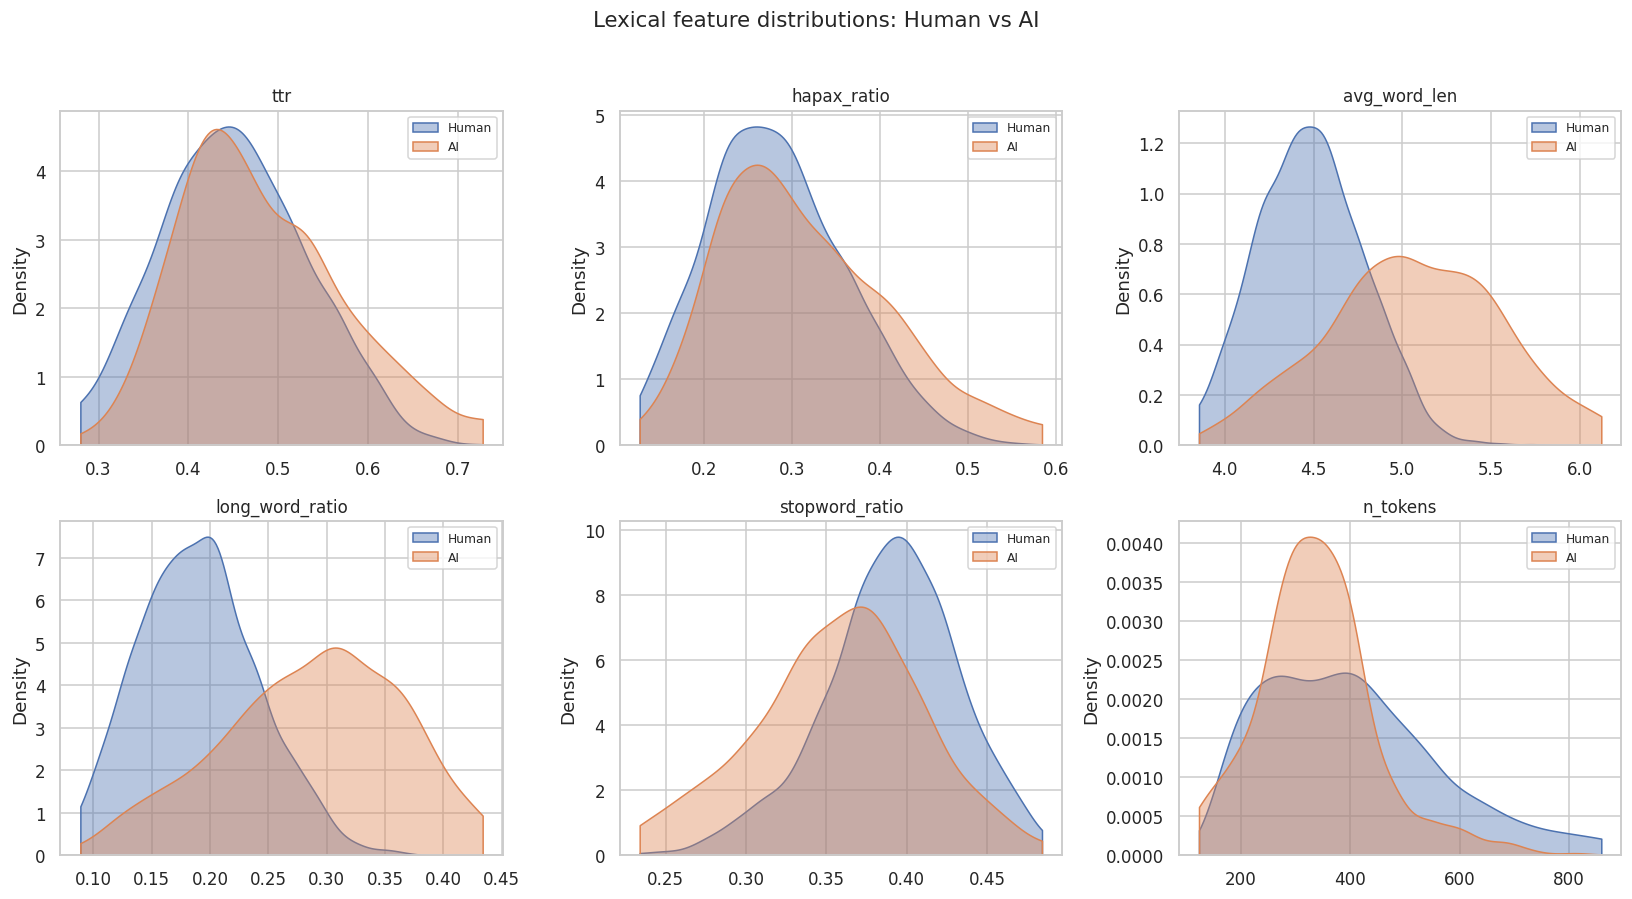

In [ ]:
# Distribution of each lexical feature, split by class
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), FEATURE_COLS):
    for cls in ['Human', 'AI']:
        sns.kdeplot(df.loc[df['label_name'] == cls, col], ax=ax,
                    fill=True, alpha=0.4, color=PALETTE[cls], label=cls, clip=(df[col].quantile(0.01), df[col].quantile(0.99)))
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(''); ax.legend(fontsize=8)
fig.suptitle('Lexical feature distributions: Human vs AI', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

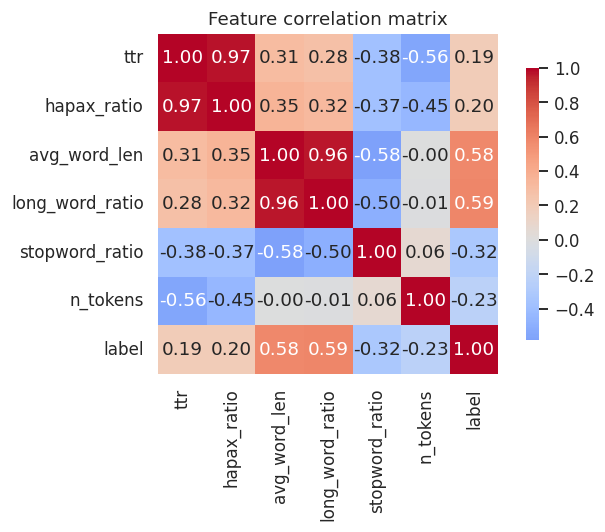

In [ ]:
# How correlated are the features (and with the label)?
fig, ax = plt.subplots(figsize=(6.5, 5))
corr = df[FEATURE_COLS + ['label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout(); plt.show()

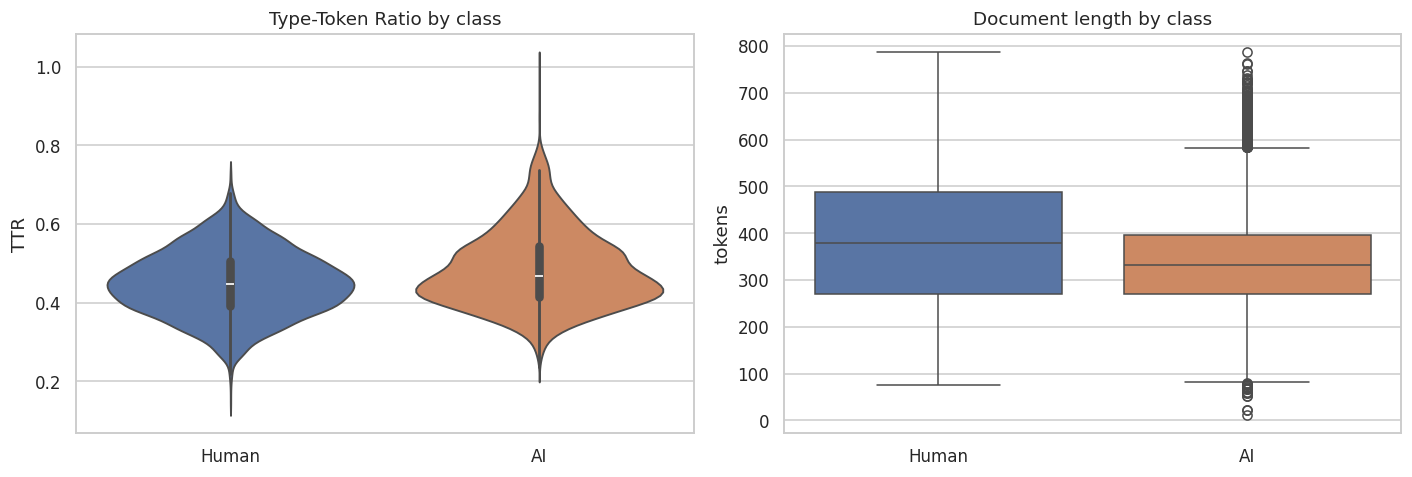

In [ ]:
# Token-count comparison (box + violin)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.violinplot(data=df, x='label_name', y='ttr', order=['Human','AI'],
               hue='label_name', palette=PALETTE, legend=False, ax=axes[0])
axes[0].set(title='Type-Token Ratio by class', xlabel='', ylabel='TTR')
clipped = df[df['n_tokens'] < df['n_tokens'].quantile(0.98)]
sns.boxplot(data=clipped, x='label_name', y='n_tokens', order=['Human','AI'],
            hue='label_name', palette=PALETTE, legend=False, ax=axes[1])
axes[1].set(title='Document length by class', xlabel='', ylabel='tokens')
plt.tight_layout(); plt.show()

## 4 · Train / validation / test split

We create the split **now, before** learning any representations. Word2Vec, the Keras tokenizer and the embedding matrix are all fit on the **training rows only**, so no information from the held-out test set can leak into them — a common source of over-optimistic scores. The same index arrays are reused for both the document-vector (ANN) and sequence (LSTM) representations, so the two models are always compared on identical documents.

In [ ]:
from sklearn.model_selection import train_test_split

y   = df['label'].values.astype('float32')
idx = np.arange(len(df))

# Hold out the test set FIRST. Everything data-derived (Word2Vec, the
# tokenizer, the embedding matrix) is then fit on the non-test rows only.
idx_train, idx_test = train_test_split(
    idx, test_size=CFG.test_size, stratify=y, random_state=SEED)
idx_tr, idx_val = train_test_split(
    idx_train, test_size=CFG.val_size, stratify=y[idx_train], random_state=SEED)

print(f'Train {len(idx_tr):>6} | Val {len(idx_val):>6} | Test {len(idx_test):>6}')
print('Word2Vec + tokenizer will be fit on Train+Val only — never on Test.')

Train   5734 | Val    638 | Test   1594
Word2Vec + tokenizer will be fit on Train+Val only — never on Test.


## 5 · Word2Vec embeddings

We train a **Skip-gram Word2Vec** model on the tokenised corpus to learn a dense semantic space. It is fit on the **training rows only** (no test-set leakage). These vectors both (a) let us sanity-check the corpus via nearest-neighbour queries and (b) initialise the embedding layer of the LSTM so it starts from meaningful weights instead of random noise.

In [ ]:
from gensim.models import Word2Vec

# Fit ONLY on training rows (train+val) so the test set is never seen.
train_sentences = df['tokens'].iloc[idx_train].tolist()

w2v = Word2Vec(
    sentences=train_sentences,
    vector_size=CFG.embed_dim,
    window=CFG.w2v_window,
    min_count=CFG.w2v_min_count,
    sg=1,                 # skip-gram
    workers=4,
    epochs=CFG.w2v_epochs,
    seed=SEED,
)
print(f'Vocabulary size: {len(w2v.wv):,} words (learned from training text only)')

# Peek at the learned space
for probe in ['data', 'people', 'time']:
    if probe in w2v.wv:
        sims = ', '.join(w for w, _ in w2v.wv.most_similar(probe, topn=5))
        print(f'{probe:>8} -> {sims}')

Vocabulary size: 11,299 words (learned from training text only)
    data -> collection, measurements, gathered, orbiters, collected
  people -> tootle, worldthere, citizens, elders, doodle
    time -> spend, timestudents, suaver, tame, downtime


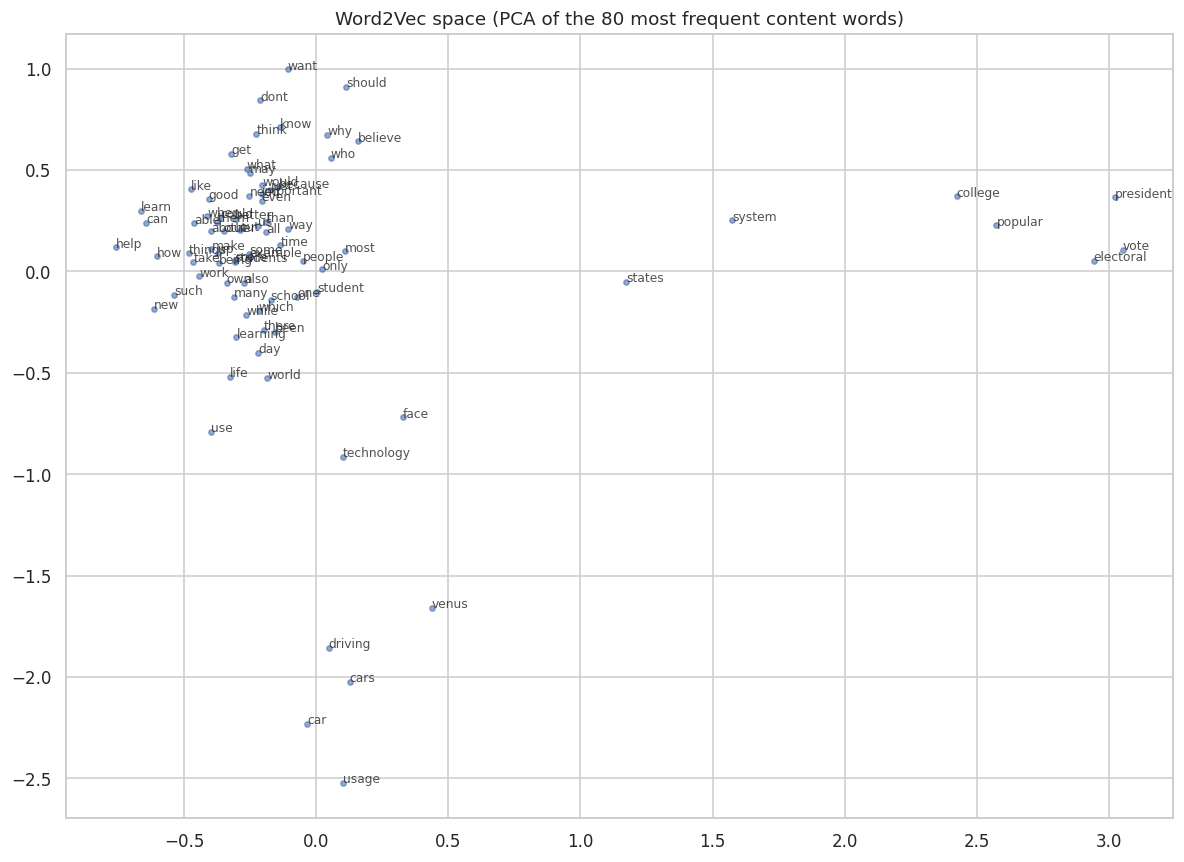

In [ ]:
# Visualise the embedding space in 2-D with PCA
from sklearn.decomposition import PCA

top_words = [w for w, _ in Counter(
    [t for toks in train_sentences for t in toks if t not in STOPWORDS]
).most_common(120)]
top_words = [w for w in top_words if w in w2v.wv][:80]
vecs = np.array([w2v.wv[w] for w in top_words])
pca = PCA(n_components=2, random_state=SEED).fit_transform(vecs)

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(pca[:, 0], pca[:, 1], s=12, color='#4C72B0', alpha=0.6)
for (px, py), w in zip(pca, top_words):
    ax.annotate(w, (px, py), fontsize=8, alpha=0.8)
ax.set_title('Word2Vec space (PCA of the 80 most frequent content words)')
plt.tight_layout(); plt.show()

## 6 · Vectorising text for the models

Two complementary representations, both derived from components fit on the **training rows only**:

* **Document vectors** (for the ANN) — the mean of a document's Word2Vec token vectors → a fixed `embed_dim`-length vector.
* **Padded integer sequences** (for the LSTM) — a Keras `Tokenizer` (fit on training text) maps words to ids; we build an **embedding matrix** from Word2Vec so the LSTM's embedding layer starts pre-trained.

Finally we slice both representations into train / validation / test using the shared indices from Section 4.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- (a) Mean Word2Vec document vectors (for the ANN) ---------------
def document_vector(tokens):
    vs = [w2v.wv[w] for w in tokens if w in w2v.wv]
    return np.mean(vs, axis=0) if vs else np.zeros(CFG.embed_dim, dtype='float32')

X_doc = np.vstack(df['tokens'].apply(document_vector).values).astype('float32')
print('Document-vector matrix:', X_doc.shape)

# --- (b) Padded sequences + embedding matrix (for the LSTM) ---------
# Fit the tokenizer on TRAINING text only, then transform every document.
tokenizer = Tokenizer(num_words=CFG.vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean'].iloc[idx_train])
seqs  = tokenizer.texts_to_sequences(df['clean'])
X_seq = pad_sequences(seqs, maxlen=CFG.max_len, padding='post', truncating='post')
print('Sequence matrix       :', X_seq.shape)

word_index = tokenizer.word_index
n_words = min(CFG.vocab_size, len(word_index) + 1)
embedding_matrix = np.zeros((n_words, CFG.embed_dim), dtype='float32')
hits = 0
for word, i in word_index.items():
    if i >= n_words:
        continue
    if word in w2v.wv:
        embedding_matrix[i] = w2v.wv[word]
        hits += 1
print(f'Embedding matrix      : {embedding_matrix.shape}  ({hits:,} words initialised from Word2Vec)')

# --- (c) Slice into train / val / test with the shared indices ------
def split(M):
    """Slice any full-length array into (train, val, test)."""
    return M[idx_tr], M[idx_val], M[idx_test]

Xd_tr, Xd_val, Xd_te = split(X_doc)
Xs_tr, Xs_val, Xs_te = split(X_seq)
y_tr,  y_val,  y_te  = split(y)
print(f'Split -> Train {len(idx_tr)} | Val {len(idx_val)} | Test {len(idx_test)}')

Document-vector matrix: (7966, 100)
Sequence matrix       : (7966, 400)
Embedding matrix      : (20000, 100)  (11,299 words initialised from Word2Vec)
Split -> Train 5734 | Val 638 | Test 1594


## 7 · Model A — Feed-forward ANN on Word2Vec document vectors

A compact fully-connected network over the mean-pooled embeddings. It is fast, hard to overfit and forms a strong baseline that tells us how much signal lives in *aggregate* semantics alone.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, Input,
                                     Embedding, SpatialDropout1D, Bidirectional,
                                     LSTM, GlobalMaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import Constant

def build_ann(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid'),
    ], name='ANN_Word2Vec')
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

ann = build_ann(CFG.embed_dim)
ann.summary()

Model: "ANN_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,097 (266.00 KB)

 Trainable params: 67,585 (264.00 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
# Fresh callback instances per model (callbacks hold internal state, so
# never share the same objects across two .fit() calls).
def make_callbacks(patience=5):
    return [
        EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
    ]

hist_ann = ann.fit(
    Xd_tr, y_tr,
    validation_data=(Xd_val, y_val),
    epochs=CFG.epochs,
    batch_size=CFG.batch_size,
    callbacks=make_callbacks(patience=5),
    verbose=2,
)

Epoch 1/20
45/45 - 7s - 157ms/step - accuracy: 0.8835 - loss: 0.2679 - val_accuracy: 0.9545 - val_loss: 0.4978 - learning_rate: 0.0010
Epoch 2/20
45/45 - 0s - 5ms/step - accuracy: 0.9576 - loss: 0.1187 - val_accuracy: 0.9639 - val_loss: 0.4397 - learning_rate: 0.0010
Epoch 3/20
45/45 - 0s - 4ms/step - accuracy: 0.9623 - loss: 0.1102 - val_accuracy: 0.9561 - val_loss: 0.3884 - learning_rate: 0.0010
Epoch 4/20
45/45 - 0s - 4ms/step - accuracy: 0.9642 - loss: 0.1003 - val_accuracy: 0.9639 - val_loss: 0.3299 - learning_rate: 0.0010
Epoch 5/20
45/45 - 0s - 5ms/step - accuracy: 0.9662 - loss: 0.0910 - val_accuracy: 0.9671 - val_loss: 0.2757 - learning_rate: 0.0010
Epoch 6/20
45/45 - 0s - 5ms/step - accuracy: 0.9716 - loss: 0.0754 - val_accuracy: 0.9639 - val_loss: 0.2202 - learning_rate: 0.0010
Epoch 7/20
45/45 - 0s - 4ms/step - accuracy: 0.9717 - loss: 0.0751 - val_accuracy: 0.9655 - val_loss: 0.1774 - learning_rate: 0.0010
Epoch 8/20
45/45 - 0s - 4ms/step - accuracy: 0.9744 - loss: 0.0738 

## 8 · Model B — Bidirectional LSTM on Word2Vec sequence embeddings

The LSTM reads the token *sequence* in both directions, so it can capture **long-term sequential dependencies** and word-order patterns that the ANN's bag-of-vectors averaging throws away. The embedding layer is seeded with our Word2Vec matrix and fine-tuned during training.

> **Which model wins is data-dependent.** On a corpus that is already well separated by vocabulary alone (like the formal-essay dataset here), the mean-pooled **ANN is a very strong, much cheaper baseline** and can match or beat the LSTM. The LSTM's advantage grows on harder data where *word order* matters. **Give the LSTM a GPU and enough epochs** — on CPU it trains slowly and, if stopped early, will look worse than it really is.

In [ ]:
def build_lstm():
    model = Sequential([
        Input(shape=(CFG.max_len,)),
        Embedding(input_dim=n_words, output_dim=CFG.embed_dim,
                  embeddings_initializer=Constant(embedding_matrix),
                  trainable=True, mask_zero=False),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(96, return_sequences=True)),  # single layer = far faster, converges quicker
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid'),
    ], name='BiLSTM_Word2Vec')
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm = build_lstm()
lstm.summary()

Model: "BiLSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 400, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 400, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 400, 192)       │       151,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 192)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,163,713 (8.25 MB)

 Trainable params: 2,163,713 (8.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# patience is a bit higher here: the LSTM needs more epochs to converge
# than the ANN, so we give it room before early-stopping.
hist_lstm = lstm.fit(
    Xs_tr, y_tr,
    validation_data=(Xs_val, y_val),
    epochs=CFG.epochs,
    batch_size=CFG.batch_size,
    callbacks=make_callbacks(patience=6),
    verbose=2,
)

Epoch 1/20
45/45 - 8s - 183ms/step - accuracy: 0.7829 - loss: 0.4530 - val_accuracy: 0.9060 - val_loss: 0.2089 - learning_rate: 0.0010
Epoch 2/20
45/45 - 2s - 49ms/step - accuracy: 0.8919 - loss: 0.2708 - val_accuracy: 0.9373 - val_loss: 0.1477 - learning_rate: 0.0010
Epoch 3/20
45/45 - 2s - 52ms/step - accuracy: 0.9494 - loss: 0.1438 - val_accuracy: 0.9687 - val_loss: 0.0993 - learning_rate: 0.0010
Epoch 4/20
45/45 - 2s - 52ms/step - accuracy: 0.9618 - loss: 0.1096 - val_accuracy: 0.9718 - val_loss: 0.0960 - learning_rate: 0.0010
Epoch 5/20
45/45 - 2s - 50ms/step - accuracy: 0.9697 - loss: 0.0858 - val_accuracy: 0.9734 - val_loss: 0.0809 - learning_rate: 0.0010
Epoch 6/20
45/45 - 2s - 49ms/step - accuracy: 0.9787 - loss: 0.0632 - val_accuracy: 0.9765 - val_loss: 0.0819 - learning_rate: 0.0010
Epoch 7/20
45/45 - 2s - 50ms/step - accuracy: 0.9792 - loss: 0.0610 - val_accuracy: 0.9812 - val_loss: 0.0743 - learning_rate: 0.0010
Epoch 8/20
45/45 - 2s - 50ms/step - accuracy: 0.9833 - loss: 

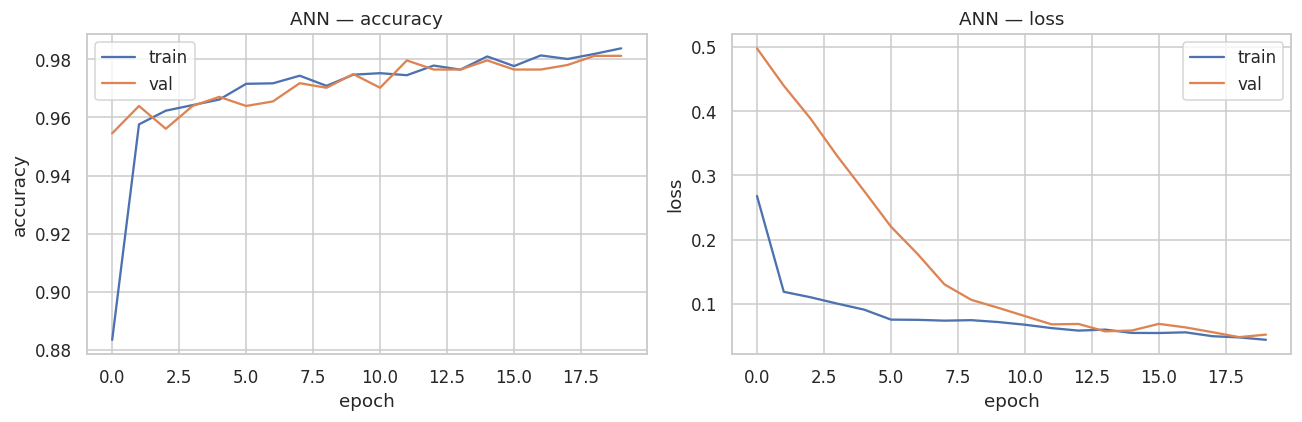

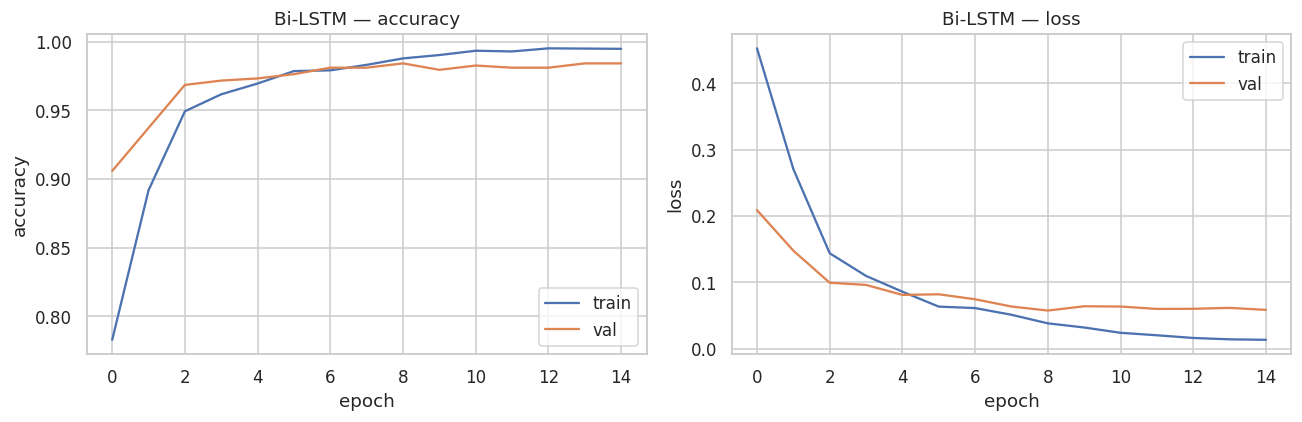

In [ ]:
# Training curves for both models
def plot_history(hist, title):
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h['accuracy'], label='train'); ax[0].plot(h['val_accuracy'], label='val')
    ax[0].set(title=f'{title} — accuracy', xlabel='epoch', ylabel='accuracy'); ax[0].legend()
    ax[1].plot(h['loss'], label='train'); ax[1].plot(h['val_loss'], label='val')
    ax[1].set(title=f'{title} — loss', xlabel='epoch', ylabel='loss'); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(hist_ann,  'ANN')
plot_history(hist_lstm, 'Bi-LSTM')

## 9 · Evaluation & head-to-head comparison

We score both models on the held-out test set with accuracy, a full classification report, confusion matrices and ROC curves.

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score, accuracy_score)

def evaluate(model, X_te, name):
    proba = model.predict(X_te, verbose=0).ravel()
    pred  = (proba >= 0.5).astype(int)
    acc   = accuracy_score(y_te, pred)
    auc   = roc_auc_score(y_te, proba)
    print(f'\n===== {name} =====')
    print(f'Accuracy: {acc:.4f}   |   ROC-AUC: {auc:.4f}')
    print(classification_report(y_te, pred, target_names=['Human', 'AI'], digits=4))
    return dict(name=name, proba=proba, pred=pred, acc=acc, auc=auc)

res_ann  = evaluate(ann,  Xd_te, 'ANN (Word2Vec doc-vectors)')
res_lstm = evaluate(lstm, Xs_te, 'Bi-LSTM (Word2Vec sequences)')


===== ANN (Word2Vec doc-vectors) =====
Accuracy: 0.9768   |   ROC-AUC: 0.9973
              precision    recall  f1-score   support

       Human     0.9822    0.9710    0.9766       794
          AI     0.9716    0.9825    0.9770       800

    accuracy                         0.9768      1594
   macro avg     0.9769    0.9768    0.9768      1594
weighted avg     0.9768    0.9768    0.9768      1594


===== Bi-LSTM (Word2Vec sequences) =====
Accuracy: 0.9768   |   ROC-AUC: 0.9972
              precision    recall  f1-score   support

       Human     0.9797    0.9736    0.9766       794
          AI     0.9739    0.9800    0.9769       800

    accuracy                         0.9768      1594
   macro avg     0.9768    0.9768    0.9768      1594
weighted avg     0.9768    0.9768    0.9768      1594



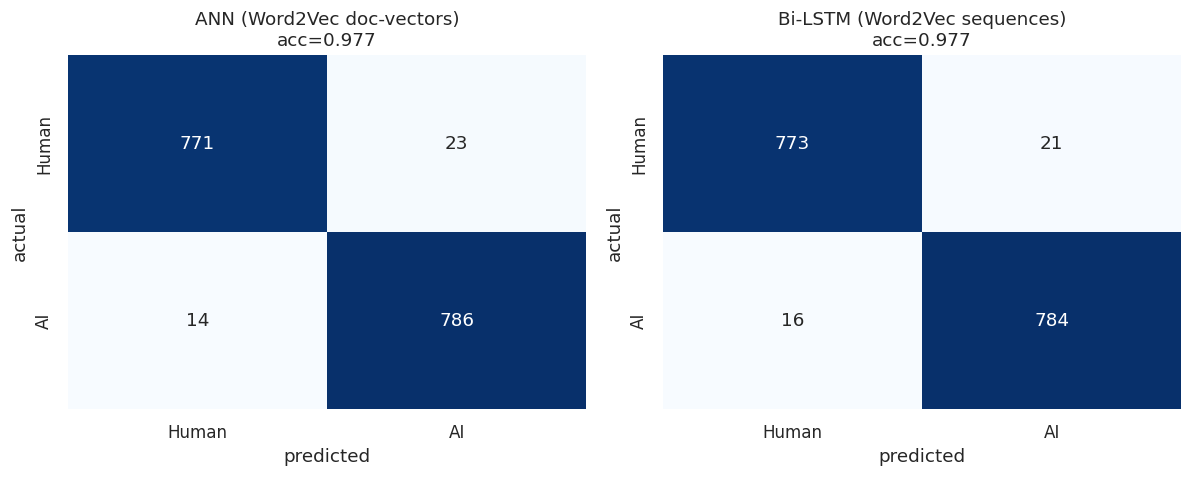

In [ ]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, res in zip(axes, [res_ann, res_lstm]):
    cm = confusion_matrix(y_te, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], ax=ax)
    ax.set(title=f"{res['name']}\nacc={res['acc']:.3f}", xlabel='predicted', ylabel='actual')
plt.tight_layout(); plt.show()

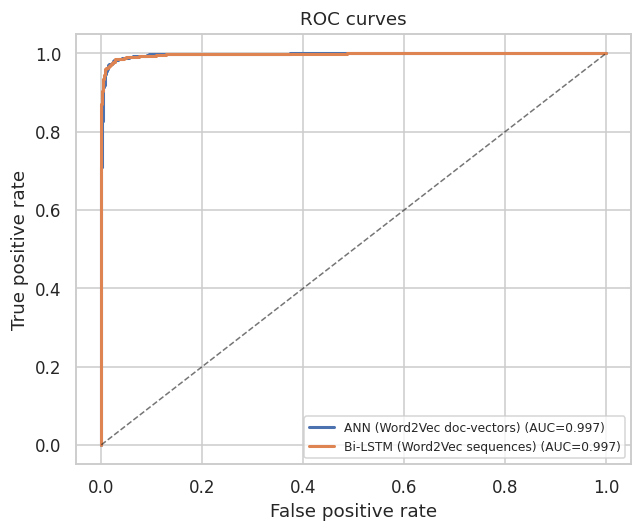

In [ ]:
# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
for res, color in zip([res_ann, res_lstm], ['#4C72B0', '#DD8452']):
    fpr, tpr, _ = roc_curve(y_te, res['proba'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{res['name']} (AUC={res['auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
ax.set(title='ROC curves', xlabel='False positive rate', ylabel='True positive rate')
ax.legend(loc='lower right', fontsize=8); plt.tight_layout(); plt.show()

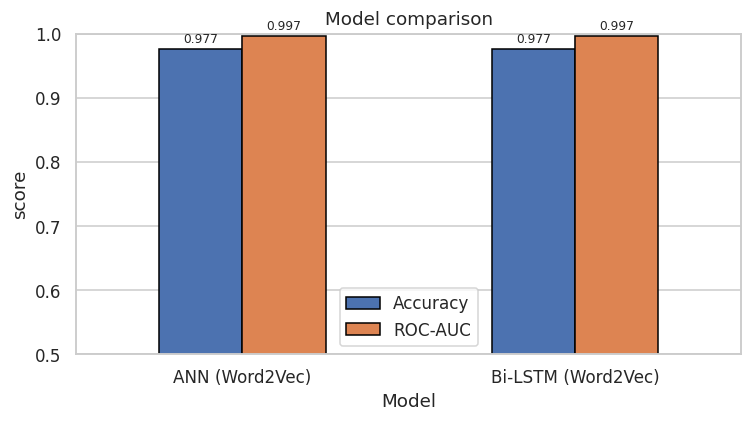

,Accuracy,ROC-AUC
Model,,
ANN (Word2Vec),0.9768,0.9973
Bi-LSTM (Word2Vec),0.9768,0.9972


In [ ]:
# Final scoreboard
scores = pd.DataFrame([
    {'Model': 'ANN (Word2Vec)',      'Accuracy': res_ann['acc'],  'ROC-AUC': res_ann['auc']},
    {'Model': 'Bi-LSTM (Word2Vec)',  'Accuracy': res_lstm['acc'], 'ROC-AUC': res_lstm['auc']},
]).set_index('Model')

fig, ax = plt.subplots(figsize=(7, 4))
scores.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='black')
ax.set(title='Model comparison', ylabel='score', ylim=(min(0.5, scores.min().min()-0.05), 1.0))
ax.set_xticklabels(scores.index, rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout(); plt.show()
scores.round(4)

## 10 · Score your own text

Drop any passage into `predict` to get a probability that it is AI-generated. By default it uses the stronger model (whichever scored highest on the test set).

In [ ]:
BEST = 'lstm' if res_lstm['acc'] >= res_ann['acc'] else 'ann'
print(f'Using best model: {BEST.upper()}\n')

def predict(text, which=BEST):
    toks = tokenize(text)
    if which == 'ann':
        vec = document_vector(toks)[None, :]
        p = float(ann.predict(vec, verbose=0).ravel()[0])
    else:
        seq = pad_sequences(tokenizer.texts_to_sequences([clean_text(text)]),
                            maxlen=CFG.max_len, padding='post', truncating='post')
        p = float(lstm.predict(seq, verbose=0).ravel()[0])
    label = 'AI-generated' if p >= 0.5 else 'Human-written'
    conf = p if p >= 0.5 else 1 - p
    return label, conf, p

samples = [
    # 1) In-domain, human-written essay sentence  -> expected: Human
    ("In my opinion students should be allowed to bring their phones to school, "
     "because a phone lets them look things up quickly and call their parents if "
     "something goes wrong."),
    # 2) In-domain, AI-style formal prose         -> expected: AI
    ("Furthermore, it is important to note that leveraging a systematic, data-driven "
     "approach enables organizations to optimize outcomes across multiple dimensions."),
    # 3) OUT-OF-DOMAIN casual slang               -> known hard case for a formal-essay model
    ("ngl i totally forgot we had that meeting today lol, ended up just grabbing "
     "coffee and heading home"),
]
tags = ['in-domain human', 'in-domain AI   ', 'out-of-domain  ']

# Show BOTH models so you can see where they agree / disagree.
for tag, s in zip(tags, samples):
    la, ca, _ = predict(s, 'ann')
    ll, cl, _ = predict(s, 'lstm')
    print(f'[{tag}]  ANN: {la:>13} ({ca:.0%})  |  LSTM: {ll:>13} ({cl:.0%})')
    print(f'                  {s[:68]}...\n')

print('The first two samples are in-domain and should be separated correctly.')
print('The third is a deliberate out-of-domain stress test (casual slang): a model')
print('trained only on formal essays may mislabel it — see the caveat in the conclusion.')

Using best model: LSTM

[in-domain human]  ANN: Human-written (100%)  |  LSTM: Human-written (97%)
                  In my opinion students should be allowed to bring their phones to sc...

[in-domain AI   ]  ANN:  AI-generated (100%)  |  LSTM:  AI-generated (100%)
                  Furthermore, it is important to note that leveraging a systematic, d...

[out-of-domain  ]  ANN:  AI-generated (95%)  |  LSTM:  AI-generated (97%)
                  ngl i totally forgot we had that meeting today lol, ended up just gr...

The first two samples are in-domain and should be separated correctly.
The third is a deliberate out-of-domain stress test (casual slang): a model
trained only on formal essays may mislabel it — see the caveat in the conclusion.


## 11 · Conclusion

This pipeline takes raw text all the way to a working AI-text detector:

* **Preprocessing + lexical-diversity analysis** surfaced concrete, interpretable signals — in this corpus AI text tends to show a higher type-token ratio, a higher long-word ratio and a lower stop-word ratio than human writing.
* **Leakage-safe methodology.** The test set is held out *before* any representation is learned; Word2Vec, the tokenizer and the embedding matrix are all fit on training rows only, so the reported scores are not inflated by test-set leakage.
* **Word2Vec** provided a semantic embedding space, visualised with PCA and reused to warm-start the LSTM.
* Two **custom Keras models** were compared on identical data: a fast **ANN** baseline over pooled embeddings, and a **Bidirectional LSTM** that reads word order and captures long-range dependencies.

**Honest limitations to keep in mind:**

* **Domain generalisation.** The model is trained on formal student essays, so it learns *this domain's* human-vs-AI cues rather than a universal 'AI-ness' signal. On very different text (slang, chat, tweets) accuracy drops — the inference demo includes a casual sentence as a deliberate stress test. Training on a more diverse corpus would help.
* **No sentence-level features.** The source corpus is already lower-cased and de-punctuated, so sentence-length style features are not recoverable; the analysis relies on word-level statistics instead.
* **Compute matters for the LSTM.** It needs a GPU and enough epochs to reach its potential; a CPU run stopped early will understate it.
